In [275]:
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pickle
import warnings
warnings.filterwarnings('ignore')

with open('CustomerData.csv', 'r') as f:
    lines = [line.strip().strip('"') for line in f.readlines()]
 
# Create CSV string without the outer quotes
csv_string = '\n'.join(lines)
 
df = pd.read_csv(StringIO(csv_string))
print(df.head(3))


  ï»¿"CustomerID  Age Gender       City  AnnualIncome  TotalSpent  \
0           C001   28      F  Bangalore      450000.0      120000   
1           C002   35      M     Mumbai     1200000.0      850000   
2           C003   42      F      Delhi      300000.0       75000   

   MonthlyPurchases  AvgOrderValue  AppTimeMinutes DiscountUsage  \
0                 6           2000            45.0        Medium   
1                18          12000           120.0           Low   
2                 3           1800            30.0          High   

  PreferredShoppingTime  
0                 Night  
1                 Night  
2                   Day  


In [276]:
df.isnull().sum()
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ï»¿"CustomerID         100 non-null    object 
 1   Age                    100 non-null    int64  
 2   Gender                 100 non-null    object 
 3   City                   100 non-null    object 
 4   AnnualIncome           99 non-null     float64
 5   TotalSpent             100 non-null    int64  
 6   MonthlyPurchases       100 non-null    int64  
 7   AvgOrderValue          100 non-null    int64  
 8   AppTimeMinutes         98 non-null     float64
 9   DiscountUsage          98 non-null     object 
 10  PreferredShoppingTime  99 non-null     object 
dtypes: float64(2), int64(4), object(5)
memory usage: 8.7+ KB


In [277]:
# Handle Missing Values - Numerical and Categorical
print("HANDLING MISSING VALUES")
print("="*80)

# Fill numerical missing values with mean
df['AnnualIncome'].fillna(df['AnnualIncome'].mean(), inplace=True)
df['AppTimeMinutes'].fillna(df['AppTimeMinutes'].mean(), inplace=True)

# Fill categorical missing values with mode
df['DiscountUsage'].fillna(df['DiscountUsage'].mode()[0], inplace=True)
df['PreferredShoppingTime'].fillna(df['PreferredShoppingTime'].mode()[0], inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print("\n" + "="*80)


HANDLING MISSING VALUES
Missing values after imputation:
ï»¿"CustomerID           0
Age                      0
Gender                   0
City                     0
AnnualIncome             0
TotalSpent               0
MonthlyPurchases         0
AvgOrderValue            0
AppTimeMinutes           0
DiscountUsage            0
PreferredShoppingTime    0
dtype: int64

Duplicate rows: 0



In [278]:
# Detect and remove outliers using IQR method for numerical columns (union of all outliers)
numerical_cols = ['AnnualIncome', 'TotalSpent', 'MonthlyPurchases', 'AvgOrderValue', 'AppTimeMinutes']

outlier_indices = set()

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(col_outliers)} outliers detected")
    outlier_indices.update(col_outliers.index)

outliers_df = df.loc[list(outlier_indices)]

# Save outliers to separate CSV
outliers_df.to_csv('outliers_dataset.csv', index=False)
print(f"\n{'='*50}")
print(f"Total unique outliers (union): {len(outlier_indices)}")
print(f"Outliers saved to 'outliers_dataset.csv'")

# Remove outliers from main dataset
df = df.drop(outlier_indices)
print(f"\nMain dataset after outlier removal:")
print(f"Shape: {df.shape}")
print(f"Remaining customers: {len(df)}")
print('='*50)

AnnualIncome: 8 outliers detected
TotalSpent: 10 outliers detected
MonthlyPurchases: 0 outliers detected
AvgOrderValue: 10 outliers detected
AppTimeMinutes: 6 outliers detected

Total unique outliers (union): 10
Outliers saved to 'outliers_dataset.csv'

Main dataset after outlier removal:
Shape: (90, 11)
Remaining customers: 90


In [279]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
import numpy as np

print("="*80)
print("FEATURE ENGINEERING & CLUSTERING")
print("="*80)

# Use the cleaned dataset 'df' (after outlier removal), not a copy
# Encode categorical variables
le_gender = LabelEncoder()
df['Gender_Encoded'] = le_gender.fit_transform(df['Gender'])

le_discount = LabelEncoder()
df['DiscountUsage_Encoded'] = le_discount.fit_transform(df['DiscountUsage'])

le_time = LabelEncoder()
df['PreferredShoppingTime_Encoded'] = le_time.fit_transform(df['PreferredShoppingTime'])

print("\nEncoding completed!")
print(f"Gender mapping: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")
print(f"DiscountUsage mapping: {dict(zip(le_discount.classes_, le_discount.transform(le_discount.classes_)))}")
print(f"PreferredShoppingTime mapping: {dict(zip(le_time.classes_, le_time.transform(le_time.classes_)))}")

# Select features for clustering
features = ['Age', 'Gender_Encoded', 'AnnualIncome', 'TotalSpent', 'AvgOrderValue', 
            'MonthlyPurchases', 'DiscountUsage_Encoded', 'AppTimeMinutes', 
            'PreferredShoppingTime_Encoded']

X = df[features].copy()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeatures selected for clustering: {features}")
print(f"Number of features: {len(features)}")
print(f"Dataset shape before clustering: {X.shape}")
print(f"Scaled data shape: {X_scaled.shape}")

# ELBOW METHOD & SILHOUETTE ANALYSIS to find optimal k
print("\n" + "="*80)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*80)

inertias = []
silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans_temp.labels_))

print("\nK-Means Analysis:")
print(f"{'K':<5} {'Inertia':<15} {'Silhouette Score':<20}")
print("-" * 40)
for k, inertia, sil_score in zip(K_range, inertias, silhouette_scores):
    print(f"{k:<5} {inertia:<15.2f} {sil_score:<20.4f}")

# Select optimal k (k=3 based on silhouette and elbow)
optimal_k = 3
print(f"\n✓ Selected optimal_k = {optimal_k} (based on silhouette score & elbow method)")

# Apply K-Means clustering with optimal k
print("\n" + "="*80)
print(f"APPLYING K-MEANS WITH k={optimal_k}")
print("="*80)

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nClustering completed!")
print(f"Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())

# Define segments based on ACTUAL data characteristics
print("\n" + "="*80)
print("MAPPING CLUSTERS TO CUSTOMER SEGMENTS")
print("="*80)

cluster_info = {}
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    avg_spend = cluster_data['TotalSpent'].mean()
    avg_app = cluster_data['AppTimeMinutes'].mean()
    cluster_info[cluster] = {'spend': avg_spend, 'app_usage': avg_app, 'count': len(cluster_data)}

# Map clusters to segments based on ACTUAL spending patterns
sorted_clusters = sorted(cluster_info.items(), key=lambda x: x[1]['spend'], reverse=True)
cluster_segments = {
    sorted_clusters[0][0]: "High-Value Loyal Customer",       # Highest spender
    sorted_clusters[1][0]: "Value-Seeking Regular Customer",   # Middle spender
    sorted_clusters[2][0]: "Price-Sensitive Occasional Customer"  # Lowest spender
}

df['Segment'] = df['Cluster'].map(cluster_segments)

print("\nCluster Segments Mapping (Based on Actual Data):")
for cluster in range(optimal_k):
    info = cluster_info[cluster]
    print(f"Cluster {cluster} ({cluster_segments[cluster]}): {info['count']} customers, Avg Spend: ₹{info['spend']:,.2f}, Avg App Usage: {info['app_usage']:.1f}m")

print("\n" + "="*80)


FEATURE ENGINEERING & CLUSTERING

Encoding completed!
Gender mapping: {'F': np.int64(0), 'M': np.int64(1)}
DiscountUsage mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
PreferredShoppingTime mapping: {'Day': np.int64(0), 'Night': np.int64(1)}

Features selected for clustering: ['Age', 'Gender_Encoded', 'AnnualIncome', 'TotalSpent', 'AvgOrderValue', 'MonthlyPurchases', 'DiscountUsage_Encoded', 'AppTimeMinutes', 'PreferredShoppingTime_Encoded']
Number of features: 9
Dataset shape before clustering: (90, 9)
Scaled data shape: (90, 9)

DETERMINING OPTIMAL NUMBER OF CLUSTERS

K-Means Analysis:
K     Inertia         Silhouette Score    
----------------------------------------
2     467.11          0.3551              
3     310.98          0.3820              
4     243.38          0.3537              
5     197.19          0.3707              
6     164.63          0.3930              
7     137.49          0.4095              

✓ Selected optimal_k = 3 (based on 

In [280]:
features = ['Age', 'Gender_Encoded', 'AnnualIncome', 'TotalSpent', 'AvgOrderValue', 
            'MonthlyPurchases', 'DiscountUsage_Encoded', 'AppTimeMinutes', 
            'PreferredShoppingTime_Encoded']

X = df_cluster[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features selected for clustering: {features}")
print(f"Number of features: {len(features)}")
print(f"Scaled data shape: {X_scaled.shape}")
# Apply K-Means clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

df['Cluster'] = df_cluster['Cluster']

print(f"Clustering completed!")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

Features selected for clustering: ['Age', 'Gender_Encoded', 'AnnualIncome', 'TotalSpent', 'AvgOrderValue', 'MonthlyPurchases', 'DiscountUsage_Encoded', 'AppTimeMinutes', 'PreferredShoppingTime_Encoded']
Number of features: 9
Scaled data shape: (90, 9)


Clustering completed!

Cluster distribution:
Cluster
0    19
1    50
2    21
Name: count, dtype: int64


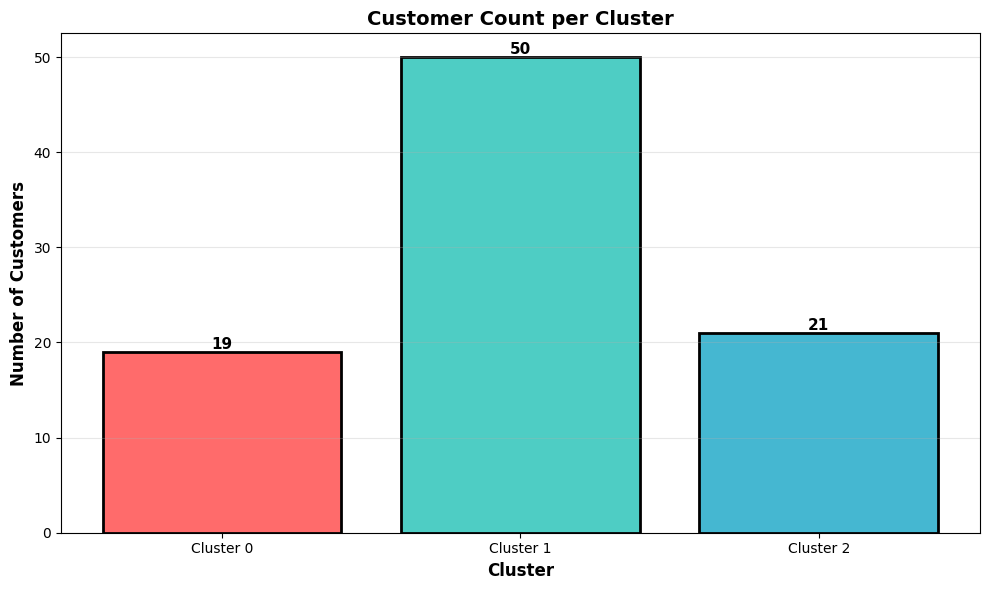

Cluster Size Distribution:
Cluster 0 (Price-Sensitive Occasional Customer): 19 customers (21.1%)
Cluster 1 (Value-Seeking Regular Customer): 50 customers (55.6%)
Cluster 2 (High-Value Loyal Customer): 21 customers (23.3%)


In [281]:
# Visualization 1: Customer Count per Cluster
fig, ax = plt.subplots(figsize=(10, 6))
cluster_counts = df['Cluster'].value_counts().sort_index()
colors_map = {0: '#FF6B6B', 1: '#4ECDC4', 2: '#45B7D1'}
bar_colors = [colors_map[int(cluster)] for cluster in cluster_counts.index]
bars = ax.bar(cluster_counts.index, cluster_counts.values, color=bar_colors, edgecolor='black', linewidth=2)

ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Customers', fontsize=12, fontweight='bold')
ax.set_title('Customer Count per Cluster', fontsize=14, fontweight='bold')
ax.set_xticks(range(optimal_k))
ax.set_xticklabels([f'Cluster {i}' for i in range(optimal_k)])

for bar, cluster in zip(bars, cluster_counts.index):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Cluster Size Distribution:")
for cluster in range(optimal_k):
    count = (df['Cluster'] == cluster).sum()
    segment = cluster_segments[cluster]
    percentage = (count / len(df)) * 100
    print(f"Cluster {cluster} ({segment}): {count} customers ({percentage:.1f}%)")


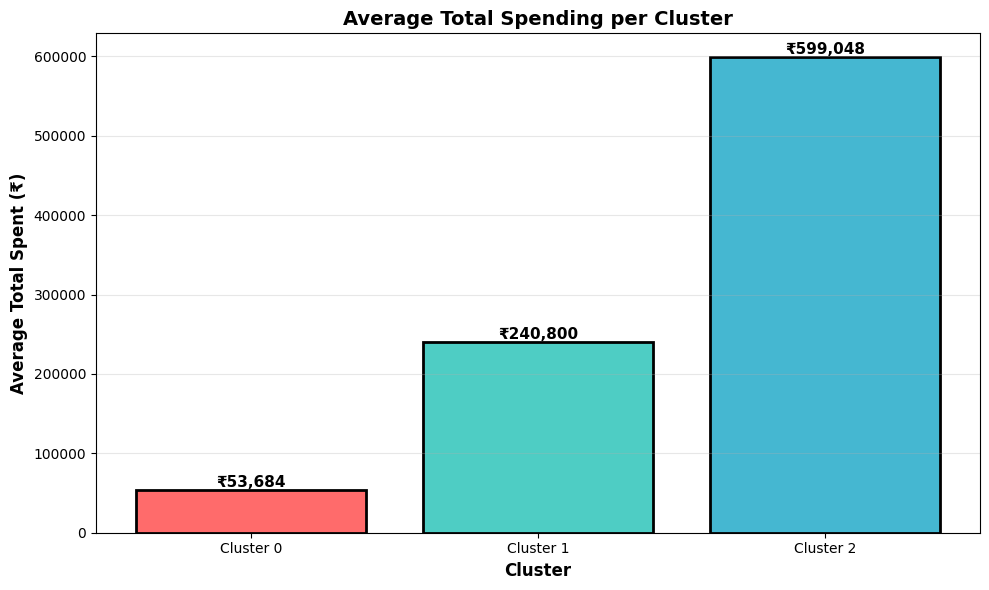

Average Spending per Cluster:
Cluster 0 (Price-Sensitive Occasional Customer): ₹53,684.21
Cluster 1 (Value-Seeking Regular Customer): ₹240,800.00
Cluster 2 (High-Value Loyal Customer): ₹599,047.62


In [282]:
# Visualization 2: Average Spending per Cluster
fig, ax = plt.subplots(figsize=(10, 6))
avg_spending = df.groupby('Cluster')['TotalSpent'].mean().sort_index()
colors_map = {0: '#FF6B6B', 1: '#4ECDC4', 2: '#45B7D1'}
bar_colors = [colors_map[int(cluster)] for cluster in avg_spending.index]
bars = ax.bar(avg_spending.index, avg_spending.values, color=bar_colors, edgecolor='black', linewidth=2)

ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Total Spent (₹)', fontsize=12, fontweight='bold')
ax.set_title('Average Total Spending per Cluster', fontsize=14, fontweight='bold')
ax.set_xticks(range(optimal_k))
ax.set_xticklabels([f'Cluster {i}' for i in range(optimal_k)])

for bar, cluster in zip(bars, avg_spending.index):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'₹{height:,.0f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Average Spending per Cluster:")
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    avg_spend = cluster_data['TotalSpent'].mean()
    segment = cluster_segments[cluster]
    print(f"Cluster {cluster} ({segment}): ₹{avg_spend:,.2f}")


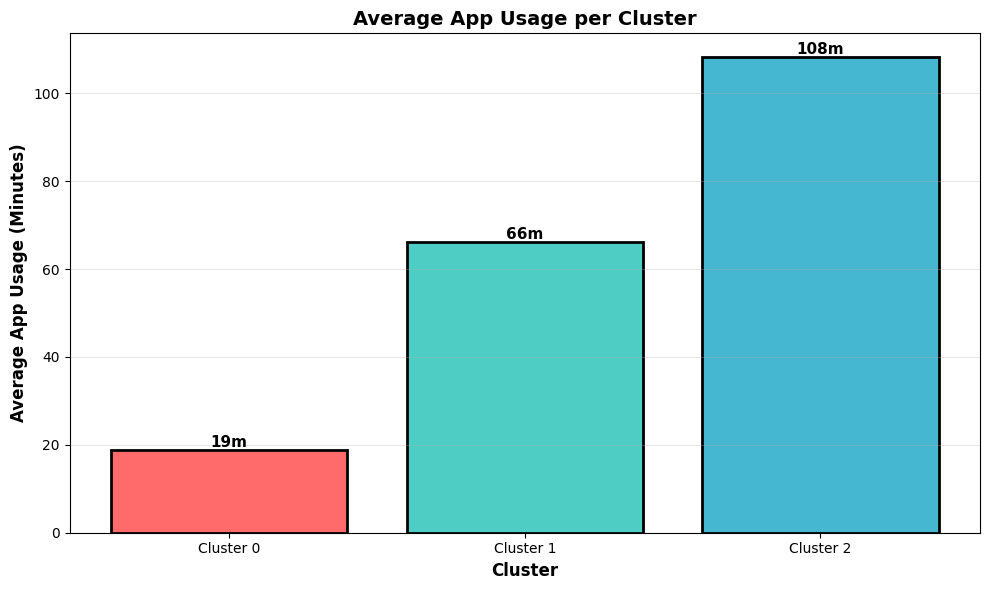

Average App Usage per Cluster:
Cluster 0 (Price-Sensitive Occasional Customer): 18.7 minutes
Cluster 1 (Value-Seeking Regular Customer): 66.1 minutes
Cluster 2 (High-Value Loyal Customer): 108.2 minutes


In [283]:
# Visualization 3: Average App Usage per Cluster
fig, ax = plt.subplots(figsize=(10, 6))
avg_app_usage = df.groupby('Cluster')['AppTimeMinutes'].mean().sort_index()
colors_map = {0: '#FF6B6B', 1: '#4ECDC4', 2: '#45B7D1'}
bar_colors = [colors_map[int(cluster)] for cluster in avg_app_usage.index]
bars = ax.bar(avg_app_usage.index, avg_app_usage.values, color=bar_colors, edgecolor='black', linewidth=2)

ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax.set_ylabel('Average App Usage (Minutes)', fontsize=12, fontweight='bold')
ax.set_title('Average App Usage per Cluster', fontsize=14, fontweight='bold')
ax.set_xticks(range(optimal_k))
ax.set_xticklabels([f'Cluster {i}' for i in range(optimal_k)])

# Add value labels on bars
for bar, cluster in zip(bars, avg_app_usage.index):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.0f}m',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Average App Usage per Cluster:")
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    avg_usage = cluster_data['AppTimeMinutes'].mean()
    segment = cluster_segments[cluster]
    print(f"Cluster {cluster} ({segment}): {avg_usage:.1f} minutes")


CLUSTER PROFILE SUMMARY


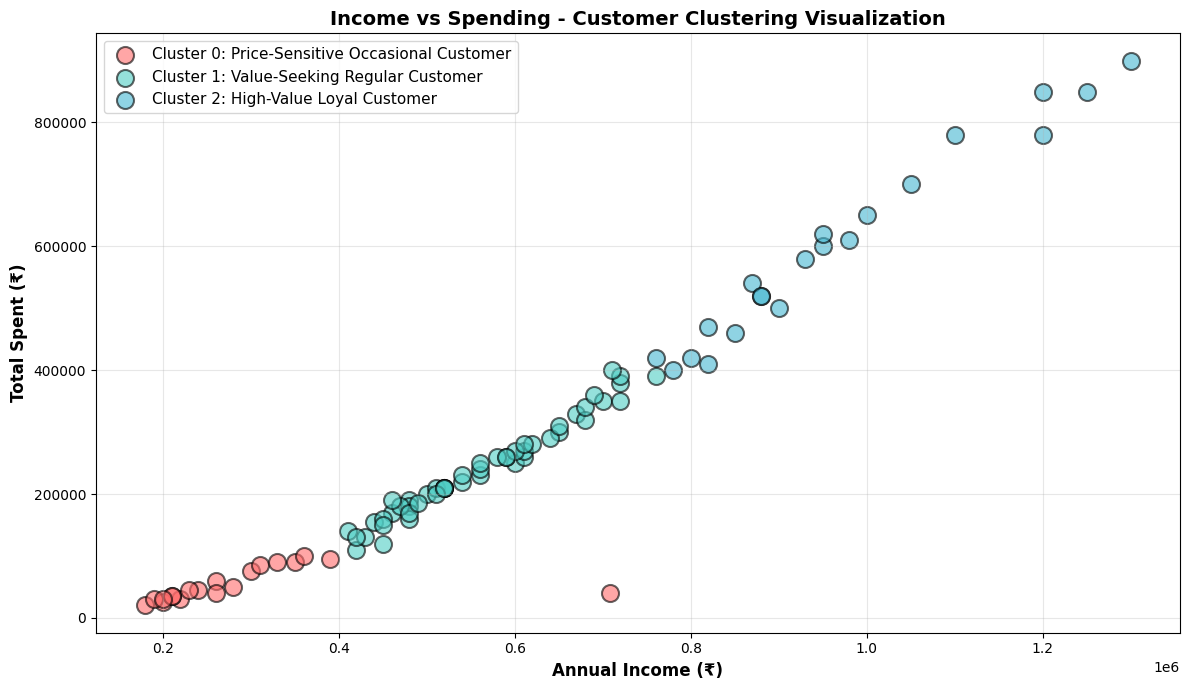


Detailed Cluster Analysis:

Price-Sensitive Occasional Customer (Cluster 0):
  Customer Count: 19
  Avg Annual Income: ₹285,725.68
  Avg Total Spent: ₹53,684.21
  Avg Monthly Purchases: 2.2
  Avg App Usage: 18.7 minutes
  Avg Order Value: ₹1,536.84

Value-Seeking Regular Customer (Cluster 1):
  Customer Count: 50
  Avg Annual Income: ₹560,600.00
  Avg Total Spent: ₹240,800.00
  Avg Monthly Purchases: 8.4
  Avg App Usage: 66.1 minutes
  Avg Order Value: ₹3,261.00

High-Value Loyal Customer (Cluster 2):
  Customer Count: 21
  Avg Annual Income: ₹965,238.10
  Avg Total Spent: ₹599,047.62
  Avg Monthly Purchases: 15.1
  Avg App Usage: 108.2 minutes
  Avg Order Value: ₹8,657.14



In [ ]:
# Visualization 4: Income vs Spending - Scatter Plot with Cluster Separation
print("="*80)
print("CLUSTER PROFILE SUMMARY")
print("="*80)

fig, ax = plt.subplots(figsize=(12, 7))
colors_map = {0: '#FF6B6B', 1: '#4ECDC4', 2: '#45B7D1'}

for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    segment_name = cluster_segments[cluster]
    color = colors_map[cluster]
    ax.scatter(cluster_data['AnnualIncome'], cluster_data['TotalSpent'], 
               s=150, alpha=0.6, label=f'Cluster {cluster}: {segment_name}',
               color=color, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Annual Income (₹)', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Spent (₹)', fontsize=12, fontweight='bold')
ax.set_title('Income vs Spending - Customer Clustering Visualization', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nDetailed Cluster Analysis:")
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    segment = cluster_segments[cluster]
    print(f"\n{segment} (Cluster {cluster}):")
    print(f"  Customer Count: {len(cluster_data)}")
    print(f"  Avg Annual Income: ₹{cluster_data['AnnualIncome'].mean():,.2f}")
    print(f"  Avg Total Spent: ₹{cluster_data['TotalSpent'].mean():,.2f}")
    print(f"  Avg Monthly Purchases: {cluster_data['MonthlyPurchases'].mean():.1f}")
    print(f"  Avg App Usage: {cluster_data['AppTimeMinutes'].mean():.1f} minutes")
    print(f"  Avg Order Value: ₹{cluster_data['AvgOrderValue'].mean():,.2f}")

print("\n" + "="*80)


In [ ]:
# Save the trained KMeans model and scaler using pickle
model_path = 'kmeans_model.pkl'
scaler_path = 'scaler.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(kmeans, f)
print(f"KMeans model saved to '{model_path}'")

with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to '{scaler_path}'")

segments_path = 'cluster_segments.pkl'
with open(segments_path, 'wb') as f:
    pickle.dump(cluster_segments, f)
print(f" Cluster segments mapping saved to '{segments_path}'")

csv_path = 'customer_clusters.csv'
df.to_csv(csv_path, index=False)
print(f"Customer data with clusters saved to '{csv_path}'")

print("\n" + "="*80)
print("All models and preprocessing objects saved successfully!")
print("Files created:")
print(f"  1. {model_path} - Trained KMeans model")
print(f"  2. {scaler_path} - StandardScaler for feature normalization")
print(f"  3. {segments_path} - Cluster to segment mapping")
print(f"  4. {csv_path} - Clustered customer data")


KMeans model saved to 'kmeans_model.pkl'
Scaler saved to 'scaler.pkl'
 Cluster segments mapping saved to 'cluster_segments.pkl'
Customer data with clusters saved to 'customer_clusters.csv'

All models and preprocessing objects saved successfully!
Files created:
  1. kmeans_model.pkl - Trained KMeans model
  2. scaler.pkl - StandardScaler for feature normalization
  3. cluster_segments.pkl - Cluster to segment mapping
  4. customer_clusters.csv - Clustered customer data
